# Exploratory Data Analysis on UCI Diabetes 130-US Hospitals

Quick exploration of the dataset before we touch any modelling. Goal is to understand what we're working with, flag problems early, and decide what preprocessing decisions are non-negotiable.

**Dataset:** 10 years of inpatient diabetic encounters (1999-2008) across 130 US hospitals. 101k rows, 50 columns. Target is `readmitted` on whether the patient came back within 30 days, after 30 days, or not at all.

In [1]:
import sys, os
if 'google.colab' in str(get_ipython()):
    REPO = 'diabetes-uci-dataset'
    REPO_URL = 'https://github.com/byambaa0325/diabetes-uci-dataset.git'
    if not os.path.exists(REPO):
        os.system(f'git clone {REPO_URL}')
    os.chdir(REPO)
    os.system('pip install -q -r requirements.txt')
    os.system('pip install -q -e .')
else:
    root = os.path.abspath(os.path.join(os.getcwd(), '../'))
    if root not in sys.path:
        sys.path.insert(0, root)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data.loader import load_raw

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df_raw, id_map = load_raw()
df = df_raw.replace('?', np.nan).copy()
print(f'{df.shape[0]:,} rows  {df.shape[1]} columns')

101,766 rows  Ã—  50 columns


## 1. Column map

50 columns across five rough groups:

| Group | Columns |
|---|---|
| IDs | `encounter_id`, `patient_nbr` |
| Demographics | `race`, `gender`, `age`, `weight` |
| Admission info | `admission_type_id`, `discharge_disposition_id`, `admission_source_id`, `payer_code`, `medical_specialty` |
| Clinical | `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_outpatient`, `number_emergency`, `number_inpatient`, `number_diagnoses`, `diag_1/2/3`, `max_glu_serum`, `A1Cresult` |
| Medications | `metformin`, `insulin`, `glipizide`, ... (No / Steady / Up / Down) |
| Target | `readmitted` |

## 2. Target distribution

Three classes: `NO`, `>30`, `<30`. The **modelling target is any readmission** — combining `<30` and `>30` into a single positive class (readmitted = 1, NO = 0). This is the binary task for Tasks 2–4. Task 5 narrows the positive class to `<30` only.

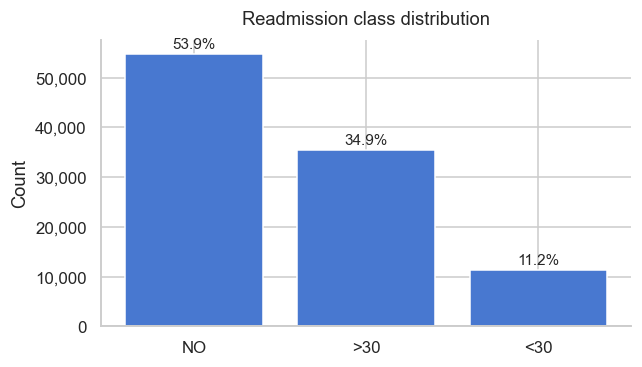

readmitted
NO     54864
>30    35545
<30    11357


In [3]:
target_counts = df['readmitted'].value_counts().reindex(['NO', '>30', '<30'])
pcts = target_counts / len(df) * 100

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(target_counts.index, target_counts.values)
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 400,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Readmission class distribution', fontsize=12, pad=10)
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.show()

print(target_counts.to_string())

**~46% readmitted** (`<30` or `>30` combined), **~54% no readmission** (`NO`). Much more balanced than the `<30`-only framing (which was ~11% positive). We still need to be careful about the threshold and recall — but class weighting is less critical here than it would be for the early-readmission-only task.

## 3. Missing data

The dataset encodes missing as `?` we've already replaced those with `NaN`. Let's see what's actually missing.

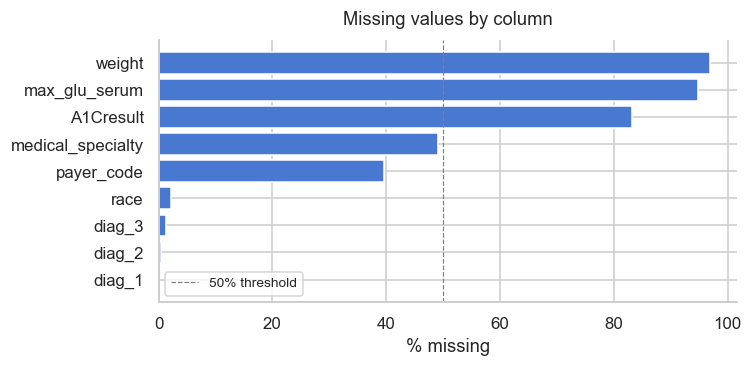

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636


In [4]:
miss_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(miss_pct.index[::-1], miss_pct.values[::-1], edgecolor='white')
ax.axvline(50, color='gray', linestyle='--', linewidth=0.8, label='50% threshold')
ax.set_xlabel('% missing')
ax.set_title('Missing values by column', fontsize=12, pad=10)
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

print(miss_pct.to_string())

`weight` (97%), `max_glu_serum` (95%), `A1Cresult` (83%) these are basically empty. `weight` is almost certainly a drop. `A1Cresult` and `max_glu_serum` are clinically relevant for diabetes so we might keep them as categorical features (present / not measured). `medical_specialty` and `payer_code` are borderline. we'll decide during feature engineering.

## 4. Duplicate encounters

Some patients appear multiple times. Depending on the task framing this could be leakage if the same patient is in train and test, the model can memorise their profile rather than generalise.

In [5]:
total = len(df)
unique_patients = df['patient_nbr'].nunique()
repeat_encounters = total - unique_patients

print(f'Total encounters : {total:,}')
print(f'Unique patients  : {unique_patients:,}')
print(f'Repeat encounters: {repeat_encounters:,}  ({repeat_encounters/total*100:.1f}%)')

encounter_counts = df.groupby('patient_nbr').size()
print(f'\nMax encounters per patient: {encounter_counts.max()}')
print('Distribution of encounters per patient:')
print(encounter_counts.value_counts().sort_index().head(8).to_string())

Total encounters : 101,766
Unique patients  : 71,518
Repeat encounters: 30,248  (29.7%)

Max encounters per patient: 40
Distribution of encounters per patient:
1    54745
2    10434
3     3328
4     1421
5      717
6      346
7      207
8      111


About 30% of rows are repeat visits from the same patient. Standard approach is to keep only the first encounter per patient to avoid leakage that's already handled in `preprocessor.py`.

## 5. Demographics

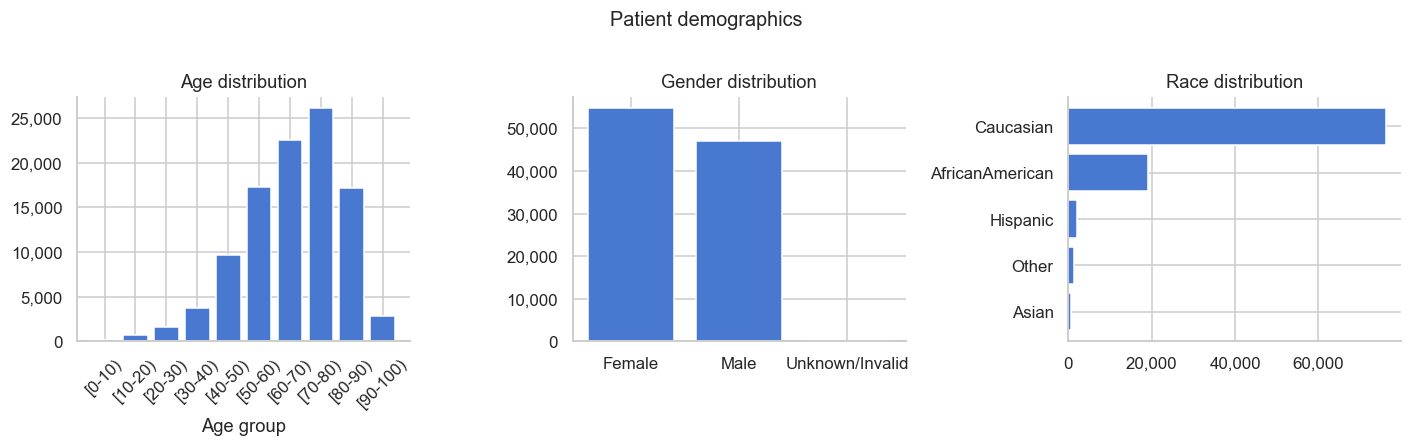

In [6]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Age
age_counts = df['age'].value_counts().reindex(age_order)
axes[0].bar(age_counts.index, age_counts.values, edgecolor='white')
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age group')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Gender
gender_counts = df['gender'].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, edgecolor='white')
axes[1].set_title('Gender distribution')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Race
race_counts = df['race'].value_counts().dropna()
axes[2].barh(race_counts.index[::-1], race_counts.values[::-1], edgecolor='white')
axes[2].set_title('Race distribution')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for ax in axes:
    sns.despine(ax=ax)
plt.suptitle('Patient demographics', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Heavily skewed toward older patients makes sense, this is an inpatient diabetes cohort. 60-80 is the modal range. Mostly Caucasian (75%), with AfricanAmerican the second largest group (19%). Worth being aware of demographic imbalance when evaluating model fairness.

## 6. Clinical features

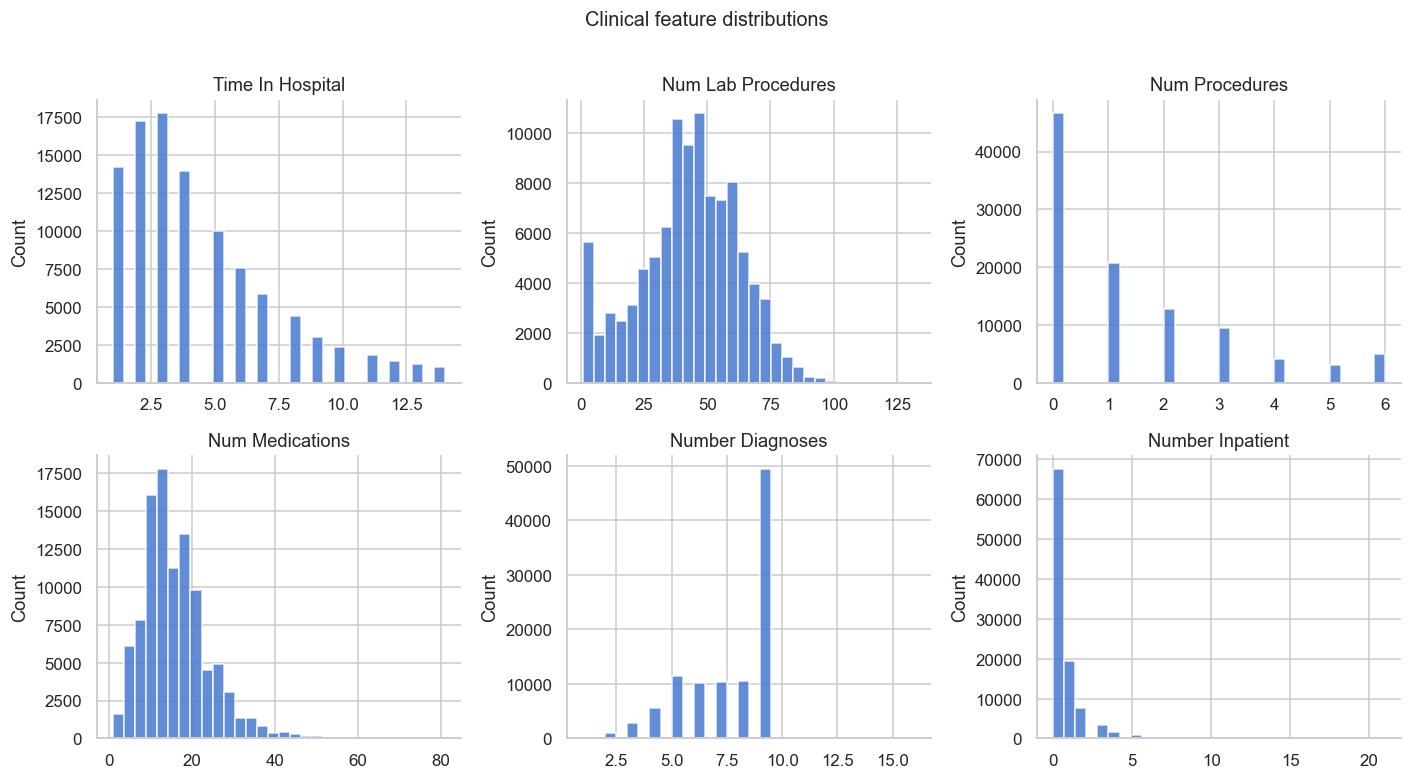

       time_in_hospital  num_lab_procedures  num_procedures  num_medications  number_diagnoses  number_inpatient
count         101766.00           101766.00       101766.00        101766.00         101766.00         101766.00
mean               4.40               43.10            1.34            16.02              7.42              0.64
std                2.99               19.67            1.71             8.13              1.93              1.26
min                1.00                1.00            0.00             1.00              1.00              0.00
25%                2.00               31.00            0.00            10.00              6.00              0.00
50%                4.00               44.00            1.00            15.00              8.00              0.00
75%                6.00               57.00            2.00            20.00              9.00              1.00
max               14.00              132.00            6.00            81.00             16.00  

In [7]:
clinical_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_diagnoses', 'number_inpatient'
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for ax, col in zip(axes, clinical_cols):
    ax.hist(df[col].dropna(), bins=30, edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylabel('Count')
    sns.despine(ax=ax)

plt.suptitle('Clinical feature distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(df[clinical_cols].describe().round(2).to_string())

A few things stand out:
- `num_lab_procedures` has a wide range  likely useful signal
- `number_inpatient` is heavily zero-inflated but the tail matters (patients with prior inpatient visits are more likely to be readmitted)
- `time_in_hospital` caps at 14 days looks like a data collection cap, not a clinical ceiling

## 7. Readmission vs clinical features

Quick look at whether the numeric features actually differ between readmitted and not.

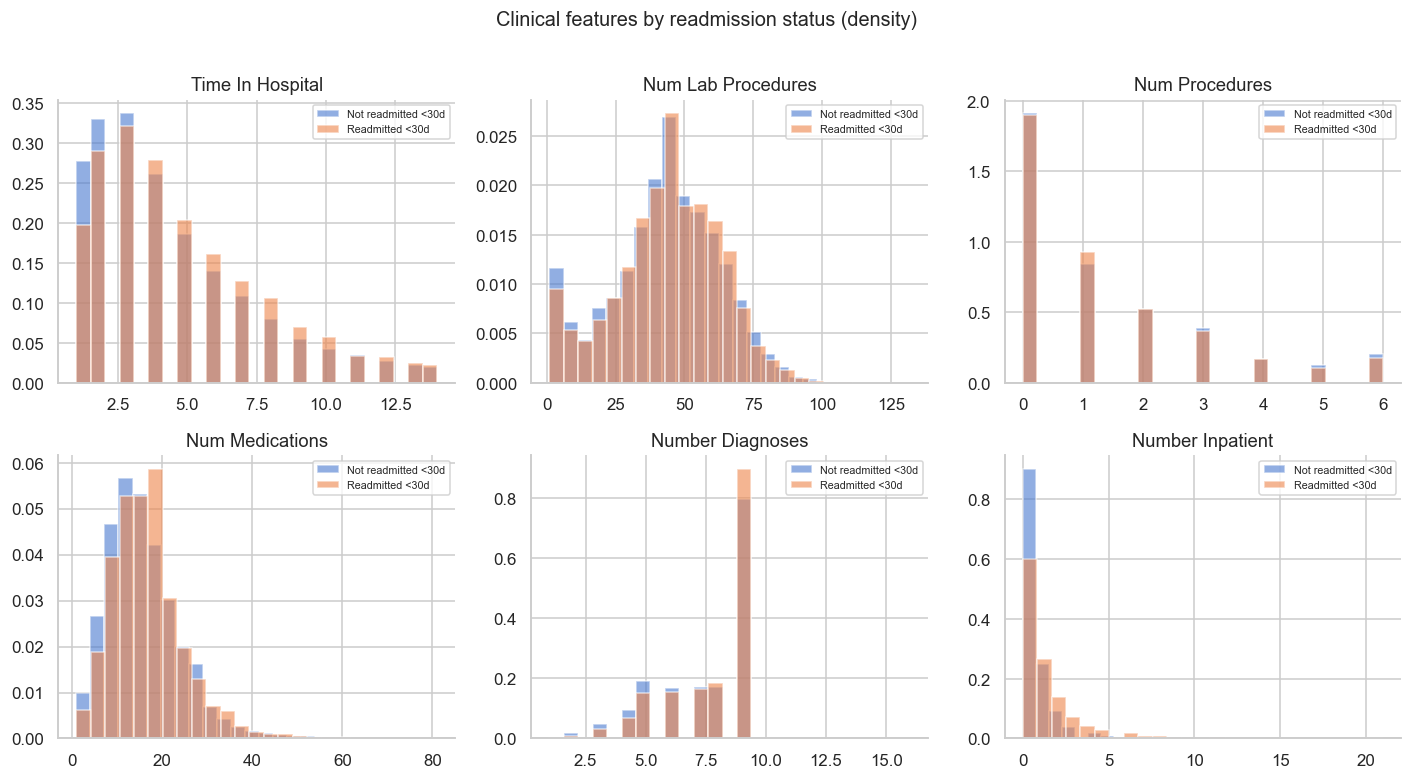

In [8]:
# Modelling target: any readmission (< 30 or > 30) vs no readmission
df['readmitted_binary'] = (df['readmitted'] != 'NO').astype(int)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for ax, col in zip(axes, clinical_cols):
    for label, grp in df.groupby('readmitted_binary'):
        ax.hist(grp[col].dropna(), bins=25, alpha=0.6,
                label='Readmitted' if label else 'Not readmitted',
                density=True)
    ax.set_title(col.replace('_', ' ').title())
    ax.legend(fontsize=7)
    sns.despine(ax=ax)

plt.suptitle('Clinical features by readmission status (density)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Distributions overlap a lot no single feature is a clean separator, which is expected. `number_inpatient` shows the most visible separation. We'll need combinations of features to get anything useful.

## 8. Medication columns

23 medication columns, each with values: `No`, `Steady`, `Up`, `Down`. Let's see which ones are actually prescribed (not just `No`).

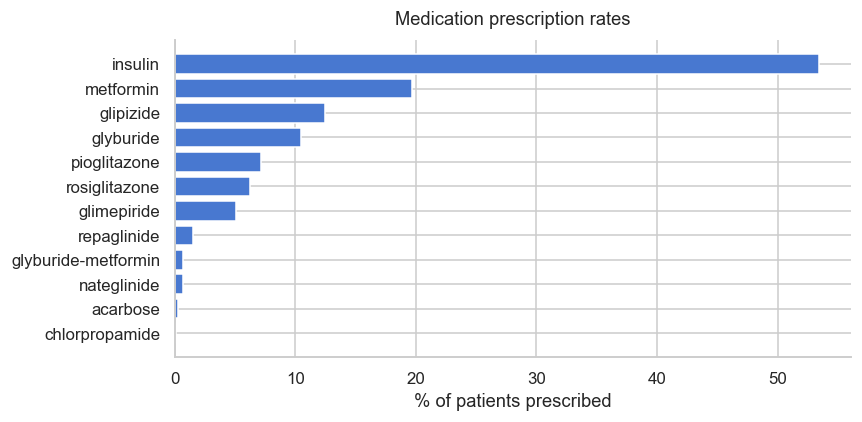

In [9]:
med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'insulin', 'glyburide-metformin'
]

prescribed_pct = {
    col: (df[col] != 'No').sum() / len(df) * 100
    for col in med_cols
}
prescribed_pct = dict(sorted(prescribed_pct.items(), key=lambda x: -x[1]))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(list(prescribed_pct.keys())[::-1], list(prescribed_pct.values())[::-1], edgecolor='white')
ax.set_xlabel('% of patients prescribed')
ax.set_title('Medication prescription rates', fontsize=12, pad=10)
sns.despine()
plt.tight_layout()
plt.show()

`insulin` dominates over half the cohort is on it. `metformin`, `glipizide`, and `glyburide` are the next most common. Several medications (`examide`, `citoglipton`, `troglitazone`) have near-zero prescription rates we'll probably drop or bin those.

## 9. Correlation heatmap (numeric features)

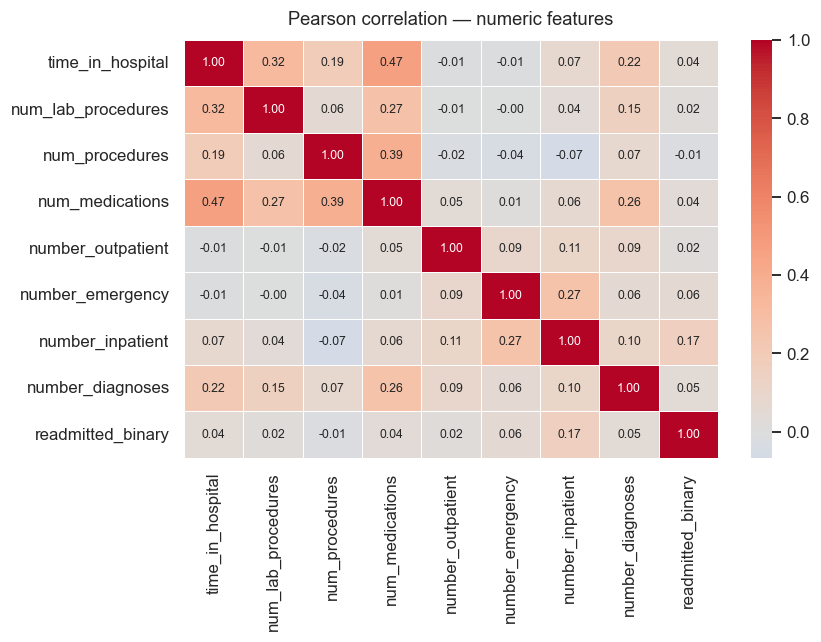

In [10]:
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses', 'readmitted_binary']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Pearson correlation â€” numeric features', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

Nothing dangerously collinear. `num_medications` and `time_in_hospital` have moderate positive correlation. makes sense since longer stays result in more medications. `number_inpatient` has the highest correlation with the target, though it's still weak (~0.1). 